In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Basic Checks

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.shape

(1338, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
pd.set_option("display.float_format", "{:.2f}".format)

In [8]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55
1334,18,female,31.92,0,no,northeast,2205.98
1335,18,female,36.85,0,no,southeast,1629.83
1336,21,female,25.80,0,no,southwest,2007.94


In [9]:
sns.set(style="whitegrid", palette="Set2", font_scale= 1.1)

In [11]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [ ]:
df.drop_duplicates(inplace = True)

In [13]:
df.duplicated().sum()

0

In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
df.describe(include = "all")

,age,sex,bmi,children,smoker,region,charges
count,1337.00,1337,1337.00,1337.00,1337,1337,1337.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.22,NaN,30.66,1.10,NaN,NaN,13279.12
std,14.04,NaN,6.10,1.21,NaN,NaN,12110.36
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.29,0.00,NaN,NaN,4746.34
50%,39.00,NaN,30.40,1.00,NaN,NaN,9386.16
75%,51.00,NaN,34.70,2.00,NaN,NaN,16657.72


### EDA

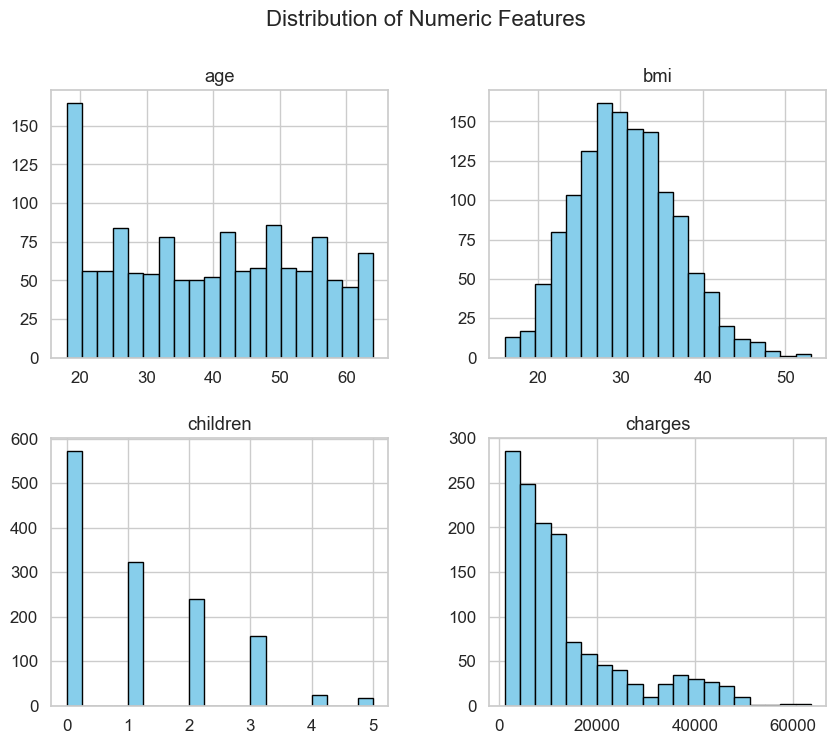

In [19]:
numeric_cols = ["age", "bmi", "children", "charges"]
df[numeric_cols].hist(bins=20, figsize=(10, 8), color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

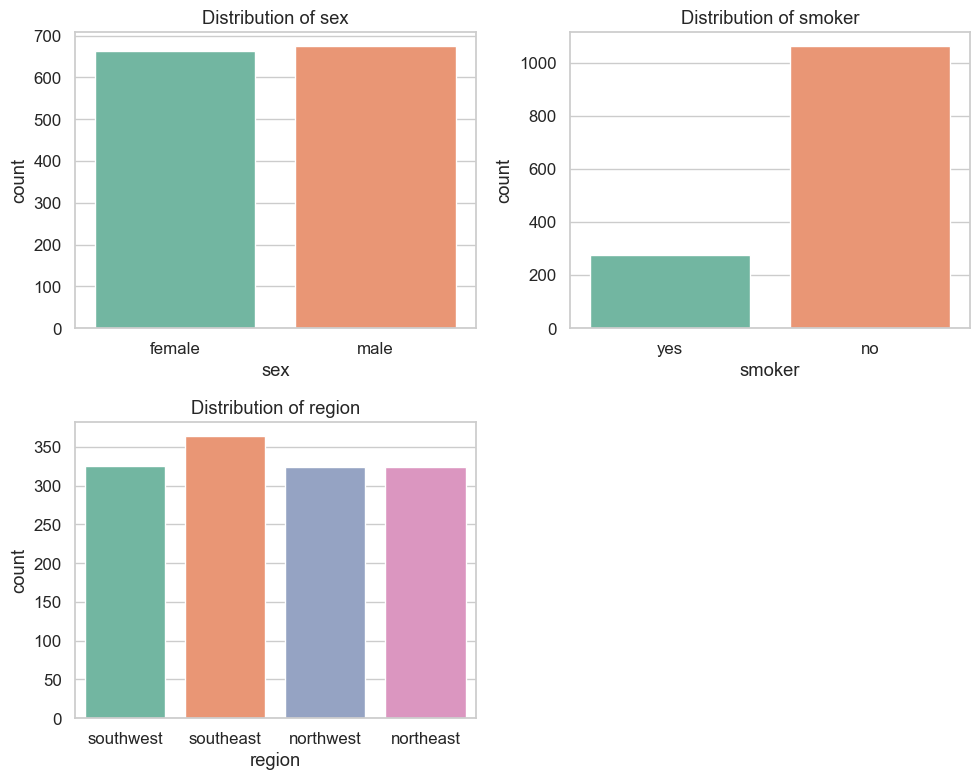

In [20]:
cat_cols = ["sex", "smoker", "region"]

plt.figure(figsize=(10,8))

for i, col in enumerate(cat_cols,1):
    plt.subplot(2,2,i)
    sns.countplot(data = df, x =col)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [21]:
df.groupby(['sex', 'smoker'])['charges'].mean().round(2)

sex     smoker
female  no        8762.30
        yes      30679.00
male    no        8099.70
        yes      33042.01
Name: charges, dtype: float64

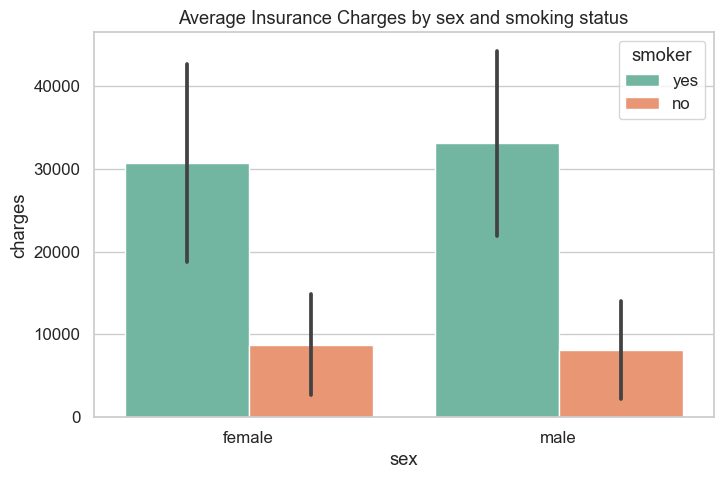

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x = "sex", y="charges", hue="smoker", estimator="mean", errorbar="sd")
plt.title("Average Insurance Charges by sex and smoking status")
plt.show()

In [ ]:
pivot_table = df.pivot_table(values = "charges", index = "region", columns = "smoker", aggfunc = "mean")
pivot_table

smoker,no,yes
region,,
northeast,9165.53,29673.54
northwest,8582.47,30192.00
southeast,8032.22,34845.00
southwest,8019.28,32269.06


In [24]:
pivot_table = df.pivot_table(values = "charges", index = "children", columns = "smoker", aggfunc = "mean")
pivot_table

smoker,no,yes
children,,
0,7624.83,31341.36
1,8303.11,31822.65
2,9493.09,33844.24
3,9614.52,32724.92
4,12121.34,26532.28
5,8183.85,19023.26


### HeatMap

In [26]:
df[numeric_cols].corr()

,age,bmi,children,charges
age,1.00,0.11,0.04,0.30
bmi,0.11,1.00,0.01,0.20
children,0.04,0.01,1.00,0.07
charges,0.30,0.20,0.07,1.00


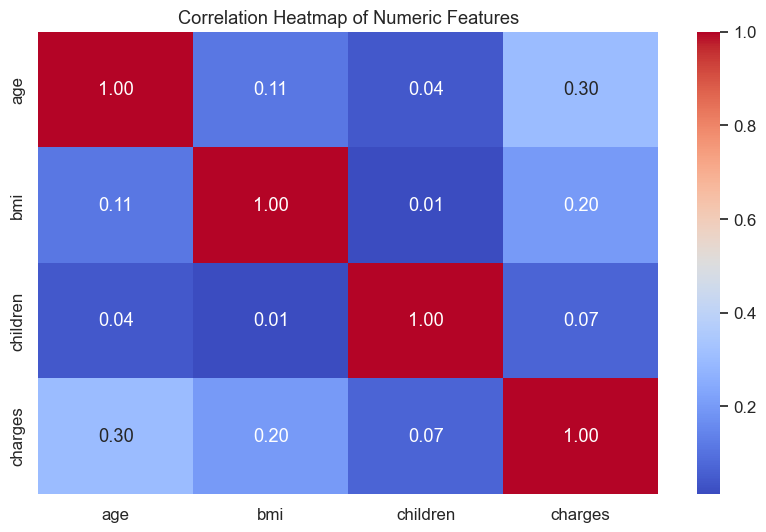

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

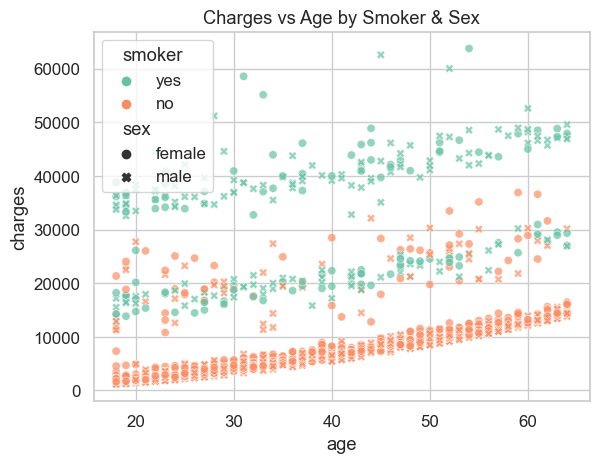

In [27]:
sns.scatterplot(data = df, x = "age", y = "charges", hue = "smoker", style = "sex", alpha = 0.7)
plt.title("Charges vs Age by Smoker & Sex")
plt.show()

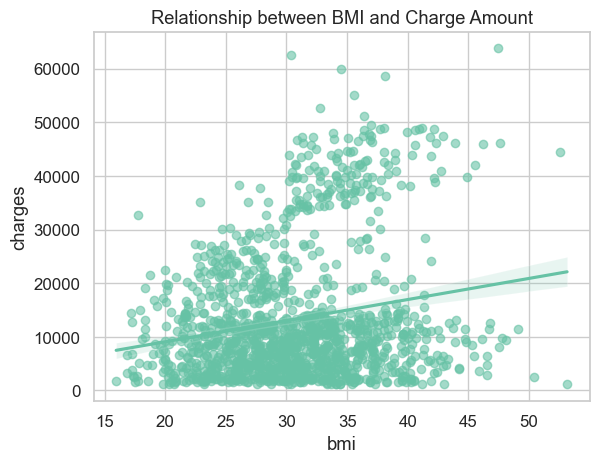

In [28]:
sns.regplot(data = df, x ="bmi", y = "charges", scatter_kws={'alpha':0.6})
plt.title("Relationship between BMI and Charge Amount")
plt.show()

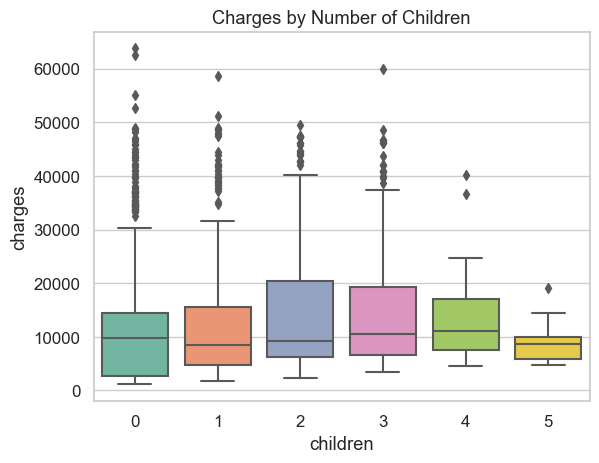

In [29]:
sns.boxplot(data = df, x = "children", y = "charges")
plt.title("Charges by Number of Children")
plt.show()

In [30]:
df["age_group"] = pd.cut(df["age"], bins = [0, 18, 30, 45, 60, 100], labels = ["<18", "18-30", "31-45", "46-60", "60+"])

In [31]:
df

,age,sex,bmi,children,smoker,region,charges,age_group
0,19,female,27.90,0,yes,southwest,16884.92,18-30
1,18,male,33.77,1,no,southeast,1725.55,<18
2,28,male,33.00,3,no,southeast,4449.46,18-30
3,33,male,22.70,0,no,northwest,21984.47,31-45
4,32,male,28.88,0,no,northwest,3866.86,31-45
...,...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55,46-60
1334,18,female,31.92,0,no,northeast,2205.98,<18
1335,18,female,36.85,0,no,southeast,1629.83,<18
1336,21,female,25.80,0,no,southwest,2007.94,18-30


In [32]:
df["age_group"].value_counts()

age_group
46-60    409
31-45    394
18-30    374
60+       91
<18       69
Name: count, dtype: int64

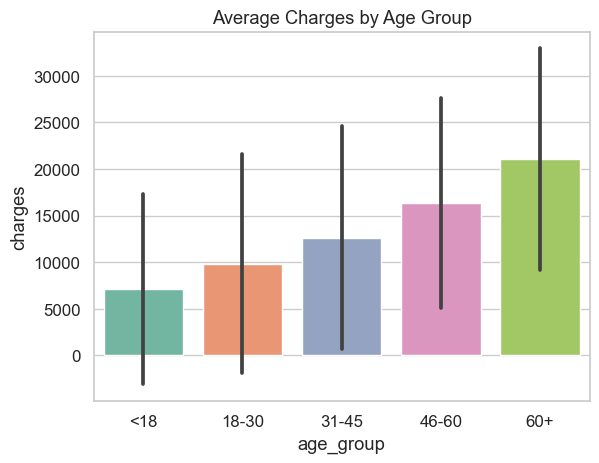

In [33]:
sns.barplot(data = df, x = "age_group", y = "charges", estimator="mean", errorbar="sd")
plt.title("Average Charges by Age Group")
plt.show()

In [34]:
df["bmi_category"] = pd.cut(df["bmi"], bins = [0, 18.5, 24.9, 29.9, 100], labels = ["underweight", "Normal", "overweight", "obese"])

In [36]:
df["bmi_category"].value_counts()

bmi_category
obese          715
overweight     380
Normal         221
underweight     21
Name: count, dtype: int64

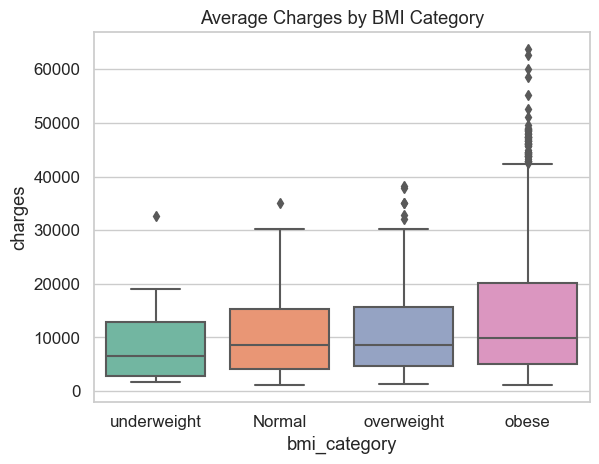

In [39]:
sns.boxplot(data = df, x = "bmi_category", y = "charges")
plt.title("Average Charges by BMI Category")
plt.show()

In [41]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x=="Yes").mean() * 100),
    mean_charge = ("charges", "mean")
).reset_index()

In [42]:
region_stats

,region,smoker_rate,mean_charge
0,northeast,0.00,13406.38
1,northwest,0.00,12450.84
2,southeast,0.00,14735.41
3,southwest,0.00,12346.94


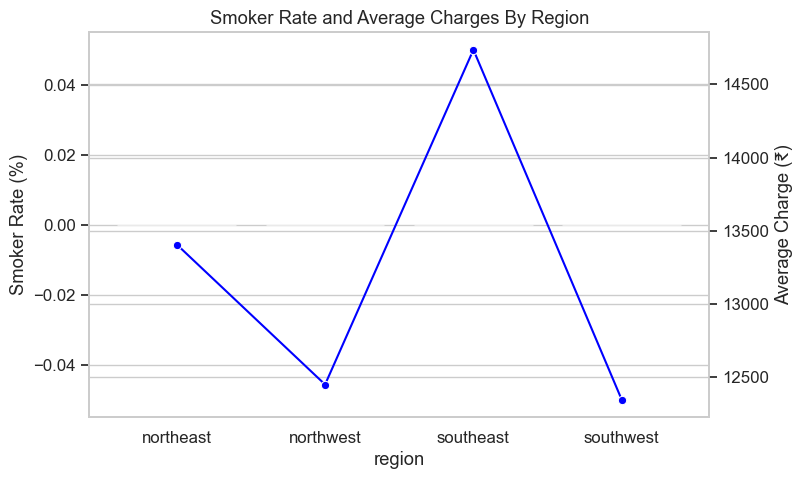

In [44]:
fig, ax1 = plt.subplots(figsize = (8,5))
sns.barplot(data = region_stats, x = "region", y ="smoker_rate", ax = ax1, alpha = 0.6)
ax2 = ax1.twinx()
sns.lineplot(data = region_stats, x = "region", y = "mean_charge", ax = ax2, color = "blue", marker = "o")

ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Charge (₹)")
plt.title("Smoker Rate and Average Charges By Region")
plt.show()

### Data Preprocessing & Feature Engineering

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [47]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_group', 'bmi_category'],
      dtype='object')

In [48]:
x = df[["age", "sex", "bmi", "children", "smoker"]]
y = df["charges"]

In [49]:
x

,age,sex,bmi,children,smoker
0,19,female,27.90,0,yes
1,18,male,33.77,1,no
2,28,male,33.00,3,no
3,33,male,22.70,0,no
4,32,male,28.88,0,no
...,...,...,...,...,...
1333,50,male,30.97,3,no
1334,18,female,31.92,0,no
1335,18,female,36.85,0,no
1336,21,female,25.80,0,no


In [50]:
cat_cols = ["sex", "smoker"]
label_encoders = {}

In [51]:
for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le

    joblib.dump(le, f"label_encoders_{col}.pkl")

In [52]:
x

,age,sex,bmi,children,smoker
0,19,0,27.90,0,1
1,18,1,33.77,1,0
2,28,1,33.00,3,0
3,33,1,22.70,0,0
4,32,1,28.88,0,0
...,...,...,...,...,...
1333,50,1,30.97,3,0
1334,18,0,31.92,0,0
1335,18,0,36.85,0,0
1336,21,0,25.80,0,0


In [53]:
label_encoders

{'sex': LabelEncoder(), 'smoker': LabelEncoder()}

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x ,y, test_size = 0.2, random_state=42)

In [55]:
num_cols = ["age", "bmi", "children"]
scaler = StandardScaler()


In [56]:
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [57]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [58]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1069, 5) (1069,)
(268, 5) (268,)


### Model

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [60]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

In [61]:
results = {}

In [64]:
lr = LinearRegression()
lr.fit(x_train, y_train)
results['Linear Regression'] = evaluate_model(lr, x_train, x_test, y_train, y_test)
print("Linear Regression model trained")

rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv = 3, scoring= "r2", n_jobs = -1, verbose = 0)
rf_grid.fit(x_train, y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf, x_train, x_test, y_train, y_test)
print("Random Forest training is complete, best parameters:", rf_grid.best_params_)

svr = SVR()

svr_params = {
    "kernel" : ["rbf", "poly", "linear"],
    "C": [1, 10, 50],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2, 3]
}

svr_grid = GridSearchCV(svr, svr_params, cv = 3, scoring = "r2", n_jobs = -1, verbose = 0)
svr_grid.fit(x_train,y_train)
best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr, x_train, x_test, y_train, y_test)
print("SVR training is complete, best parameters:", svr_grid.best_params_)

xgb = XGBRegressor(objective="reg:squarederror")

xgb_params = {
    "n_estimators" : [100, 200],
    "max_depth" : [3, 5, 7],
    "learning_rate" : [0.01, 0.05, 0.1],
    "subsample" : [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv = 3, scoring = "r2", n_jobs = -1, verbose = 0)
xgb_grid.fit(x_train, y_train)
best_xgb = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb, x_train, x_test, y_train, y_test)
print("XGBoost training is completed, best parameters:", xgb_grid.best_estimator_)

Linear Regression model trained
Random Forest training is complete, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
SVR training is complete, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.5, 'kernel': 'linear'}
XGBoost training is completed, best parameters: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=Non

In [65]:
results_df = pd.DataFrame(results).T.sort_values(by = "R2", ascending= False)
results_df

,R2,MAE,RMSE
XGBoost,0.90,2510.50,4269.96
Random Forest,0.89,2584.16,4554.37
Linear Regression,0.80,4198.11,5991.82
SVR,0.41,5162.46,10416.26


In [77]:
models = {
    "Linear Regression": lr,
    "Random Forest Regression": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [78]:
best_r2 = results_df["R2"].max()

In [79]:
best_r2

0.9007785344678982

In [80]:
top_model = results_df[results_df["R2"] == best_r2]

In [81]:
top_model

,R2,MAE,RMSE
XGBoost,0.90,2510.50,4269.96


In [82]:
best_model = models[top_model.index[0]]
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [83]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best model selected: {top_model.index[0]}")

Best model selected: XGBoost
